In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import SGD, Adam

import numpy as np

In [4]:
def print_nn_state(network):
    for key in network.state_dict.keys():
        if not key.startswith('_'):
            layer = network.state_dict[key]
            print(f'{key} input: ', layer._last_input)
            print(f'{key} weights: \n', layer.state_dict['weights'])
            print(f'{key} bias: ', layer.state_dict['bias'])
            print(f'{key} output: ', layer._last_output)
            print('=' * 60)
        

class Bias:
    def __init__(self, h_size: int) -> None:
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class Weight:
    def __init__(self, v_size: int, h_size: int):
        self._v_size = v_size
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class LinearLayer:
    def __init__(self, in_features: int, out_features: int, require_grad=True):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = Bias(out_features)()
        self.weights = Weight(in_features, out_features)()
        self._require_grad = require_grad
        self._input = None  # store input values either activated or not
        self._z_output = None  # Store output before activation
        self._a_output = None  # Store output after activation

    @property
    def state_dict(self):
        return dict(
            weights=self.weights,
            bias=self.bias,
        )

    def forward(self, x):
        """ Linear transformation W.X + B """
        self._input = x # save the input
        self._z_output = np.dot(self._input, self.weights) + self.bias # save values before activation
        return self._z_output

    def backward(self, dldy, lr):
        """ Backpropagate gradients and update weights & bias """
        
        # Compute gradient of weights and activations
        if self._a_output is None:  # No activation applied (e.g., output layer)
            dw = np.dot(self._input.T, dldy)  # Gradient of weights
            da = np.dot(dldy, self.weights.T)  # Gradient of activations for previous layer
        else:  # ReLU activation applied
            dZ = dldy * relu_derivative(self._z_output)  # Apply ReLU derivative
            dw = np.dot(self._input.T, dZ)  # Compute weight gradients
            da = np.dot(dZ, self.weights.T)  # Compute activation gradients for previous layer
    
        # Compute gradient of bias (sum over batch)
        db = np.sum(dldy, axis=0, keepdims=True)
    
        # Update weights and biases using gradient descent
        self.weights -= lr * dw  # Correct weight update
        self.bias -= lr * db  # Correct bias update
    
        return da  # Return gradient for previous layer

        
    def __call__(self, x):
        if x is None:
            return self.state_dict
        else:
            return self.forward(x)

    def __repr__(self):
        return str(self.state_dict)


class NeuralNetwork:
    
    @property
    def state_dict(self):
        return self.__dict__

    def _get_layers(self):
        return [self.state_dict[key] for key in self.state_dict.keys() if not key.startswith('_')]

    def forward(self, x):
        raise NotImplementedError('The forward() method must be implemented')

    def backward(self, y_pred, y_true, lr=0.01):

        dldy = 2 * (y_pred - y_true) / y_true.size
        
        for key in reversed(self.state_dict.keys()):
            layer = self.__getattribute__(key)
            dldy = layer.backward(dldy, lr=lr)

    def __call__(self, x):
        return self.forward(x)

    @property
    def track_functions(self) -> list:
        return self._grad_fn

    def __repr__(self):
        return self.state_dict


def relu_activation(layer, x):
    """ Applies ReLU activation function and tracks it """
    layer._a_output = np.maximum(0, x)
    return layer._a_output

def relu_derivative(x):
    return (x > 0).astype(float)

In [36]:
class TestNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(2, 2)
        self.hidden_layer = nn.Linear(2, 4)
        self.output_layer = nn.Linear(4, 3)

    def forward(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        x = F.relu(self.input_layer(x))
        x = F.relu(self.hidden_layer(x))
        return F.relu(self.output_layer(x))

In [6]:
def train_original(model, optimizer, epochs, x_true, y_true):
    losses = []
    y_true = torch.tensor(y_true, dtype=torch.float32)
    for epoch in range(epochs):
        y_pred = model.forward(x_true)
        loss = F.mse_loss(y_pred, y_true)
        losses.append(loss.detach().numpy())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:  # Print loss every 100 epochs
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return losses

In [7]:
class SingleNeuronNN(NeuralNetwork):
    def __init__(self):
        super().__init__()
        self.input_layer = LinearLayer(2, 2)
        self.hidden_layer = LinearLayer(2, 4)
        self.output_layer = LinearLayer(4, 3)

    def forward(self, x):
        x = self.input_layer(x)
        x = relu_activation(self.input_layer, x)
        x = self.hidden_layer(x)
        x = relu_activation(self.hidden_layer, x)
        x = self.output_layer(x)
        return relu_activation(self.output_layer, x)

    

def train(model, x, y_pred, y_true, epochs=1, lr=0.05):
    losses = []
    for epoch in range(epochs):
        y_pred = model.forward(x)
        
        # loss MSE
        loss = np.mean((y_pred - y_true) ** 2) / y_true.size
        losses.append(loss)
        print(f'Epoch: {epoch}, Loss: ', loss)
        model.backward(y_pred, y_true, lr=lr)
    return losses

In [8]:
x_true = np.random.randn(1, 2)
y_true = np.random.randn(1, 3)
y_pred = np.random.randn(1, 3)

In [9]:
single_neuron = SingleNeuronNN()

In [33]:
test_network = TestNetwork()
optimizer = Adam(test_network.parameters(), lr=0.03)

In [34]:
losses_original = train_original(test_network, optimizer, epochs=200, x_true=x_true, y_true=y_true)

Epoch 0, Loss: 0.8483
Epoch 50, Loss: 0.4383
Epoch 100, Loss: 0.4383
Epoch 150, Loss: 0.4383


In [28]:
losses = train(single_neuron, x=x_true, y_pred=y_pred, y_true=y_true, epochs=200, lr=0.03)

Epoch: 0, Loss:  0.23628302028924372
Epoch: 1, Loss:  0.23271209239828206
Epoch: 2, Loss:  0.22928257325180249
Epoch: 3, Loss:  0.22598886306352353
Epoch: 4, Loss:  0.22282558379870043
Epoch: 5, Loss:  0.21978757039276428
Epoch: 6, Loss:  0.2168698623177032
Epoch: 7, Loss:  0.21406769548241458
Epoch: 8, Loss:  0.21137649445380335
Epoch: 9, Loss:  0.20879186498592514
Epoch: 10, Loss:  0.20630958684497488
Epoch: 11, Loss:  0.20392560691840625
Epoch: 12, Loss:  0.20163603259692978
Epoch: 13, Loss:  0.1994371254185838
Epoch: 14, Loss:  0.19732529496450024
Epoch: 15, Loss:  0.19529709299639844
Epoch: 16, Loss:  0.19334920782623347
Epoch: 17, Loss:  0.19147845890880702
Epoch: 18, Loss:  0.18968179164851065
Epoch: 19, Loss:  0.18795627241172205
Epoch: 20, Loss:  0.18629908373671025
Epoch: 21, Loss:  0.18470751973322888
Epoch: 22, Loss:  0.18317898166428545
Epoch: 23, Loss:  0.18171097370287215
Epoch: 24, Loss:  0.18030109885673082
Epoch: 25, Loss:  0.17894705505449668
Epoch: 26, Loss:  0.1776

In [11]:
single_neuron.state_dict

{'input_layer': {'weights': array([[ 0.219946  ,  0.04101526],
        [-0.24259299, -0.27138098]]), 'bias': array([[ 0.38805177, -0.45856198]])},
 'hidden_layer': {'weights': array([[-0.20187582, -0.09287172, -0.27470139, -0.23996511],
        [-0.39356916,  0.39667181, -0.04547649,  0.39287598]]), 'bias': array([[ 0.00489681, -0.17724518, -0.428066  ,  0.14259903]])},
 'output_layer': {'weights': array([[-0.27598053, -0.46325061,  0.42572562],
        [ 0.47911711,  0.01035561, -0.38252726],
        [ 0.33132115,  0.21256159, -0.0927605 ],
        [-0.16867267,  0.05553658, -0.39279341]]), 'bias': array([[ 0.18308858,  0.23371597, -0.09586715]])}}

In [12]:
test_network.state_dict()

OrderedDict([('input_layer.weight',
              tensor([[-0.0517, -0.5015],
                      [-0.6559,  0.3698]])),
             ('input_layer.bias', tensor([-0.6182,  0.5364])),
             ('hidden_layer.weight',
              tensor([[-0.3643, -0.5362],
                      [-0.5330, -0.4943],
                      [ 0.2585,  0.6026],
                      [ 0.2363,  0.5728]])),
             ('hidden_layer.bias',
              tensor([-0.0755, -0.6737,  0.4379, -0.0175])),
             ('output_layer.weight',
              tensor([[ 0.3045,  0.1716, -0.3038,  0.2363],
                      [-0.2486, -0.1227,  0.4332,  0.3652],
                      [-0.4700, -0.3081,  0.0646,  0.0182]])),
             ('output_layer.bias', tensor([ 0.2463, -0.4601, -0.3514]))])

In [23]:
test_network.input_layer.weight

tensor([-0.0517, -0.5015], grad_fn=<SelectBackward0>)

In [25]:
single_neuron.state_dict['input_layer'].weights[0]

array([0.219946  , 0.04101526])

In [29]:
%matplotlib inline

In [30]:
import matplotlib.pyplot as plt

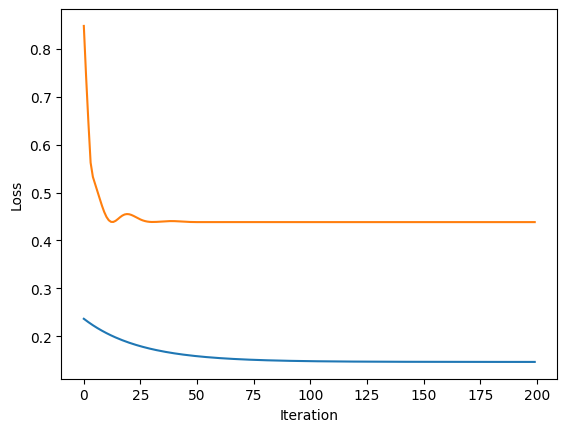

In [35]:
plt.plot(range(len(losses)), losses)
plt.plot(range(len(losses_original)), losses_original)
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.show()

In [ ]:
test_network.output_layer.state_dict()['weight'].shape

In [ ]:
single_neuron.output_layer.state_dict['weights'].shape